# Gestalt Segmentation Analysis: SegAnyMo vs HDGMM vs FlowSAM

Evaluates segmentation accuracy using probe-point sampling with NO skipping methodology.

**All methods evaluated at the same resolution (96×96) for fair comparison:**
- SegAnyMo: Downsampled from 1000×1000 → 96×96
- FlowSAM: Downsampled from 1000×1000 → 96×96  
- HDGMM: Native resolution 96×96, averaged across 5 runs

Includes categorical variance (sampling uncertainty) and inter-run variance (consistency) analysis for HDGMM.

In [1]:
import numpy as np
import os
import json
from PIL import Image
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats
import jax.numpy as jnp
import jax

In [2]:
# Configuration
GESTALT_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/assets/from_thomas'
SEGANYMO_BASE_PATH = '/home/esli/SegAnyMo/gestalt_SegAnyMo_outputs'
HDGMM_BASE_PATH = '/home/esli/GenParticles_neural_stimulus/video_gestalt_masks'
OUTPUT_DIR = '/home/esli/GenParticles_neural_stimulus/analysis_results'

SCENES = [f'scene_{i:05d}' for i in range(20)]
TEXTURES = ['texture_00', 'texture_07', 'texture_13', 'texture_16', 'texture_21', 'texture_22', 'texture_25']
NUM_FRAMES = 5
NUM_PROBES = 100
RANDOM_SEED = 42  # Global random seed for reproducibility

# Set global random seeds
np.random.seed(RANDOM_SEED)
jax.random.PRNGKey(RANDOM_SEED)  # Seed JAX random number generator

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Analyzing {len(SCENES)} scenes × {len(TEXTURES)} textures = {len(SCENES)*len(TEXTURES)} combinations")
print(f"Random seed: {RANDOM_SEED}")

Analyzing 20 scenes × 7 textures = 140 combinations
Random seed: 42


In [3]:
# Core helper functions

def load_ground_truth_mask(scene, frame_idx):
    """Load ground truth binary mask (1000×1000)"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, 'render_passes', 'masks', f'Image{frame_idx+1:04d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    if mask_img.ndim == 3:
        mask_img = mask_img[:, :, 0]
    return mask_img > 127

def load_seganymo_mask(scene, texture, frame_idx):
    """Load SegAnyMo mask (1000×1000)"""
    mask_file = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 
                              'output_six_frame', f'{frame_idx:05d}.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_flowsam_mask(scene, texture, frame_idx):
    """Load FlowSAM mask (1000×1000), colored by detected objects"""
    mask_file = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched_reprocessed', 
                              f'frame_{frame_idx:05d}_matched.png')
    if not os.path.exists(mask_file):
        return None
    mask_img = np.array(Image.open(mask_file))
    return mask_img[:, :, 0] if mask_img.ndim == 3 else mask_img

def load_hdgmm_mask_single_run(scene, texture, frame_idx, run_idx=0):
    """Load HDGMM mask from single run (96×96)"""
    path = os.path.join(HDGMM_BASE_PATH, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None
    data = np.load(path, allow_pickle=True)
    if 'pixel_hyperblob_assignments' not in data or frame_idx >= len(data['pixel_hyperblob_assignments']):
        return None
    return data['pixel_hyperblob_assignments'][frame_idx].astype(np.int32)

def load_hdgmm_mask(scene, texture, frame_idx, num_runs=5):
    """Load HDGMM mask averaged across runs using mode (96×96)"""
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) == 0:
        return None
    if len(masks) == 1:
        return masks[0]
    masks_stack = np.stack(masks, axis=0)
    mode_mask, _ = stats.mode(masks_stack, axis=0, keepdims=False)
    return mode_mask.astype(np.int32)

In [4]:
# Core evaluation function

def evaluate_segmentation_NO_SKIPPING(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Evaluate segmentation using probe-point sampling. NO SKIPPING - all segment IDs treated equally.
    Returns: (mean_accuracy, probe_accuracies)
    """
    if true_mask is None or predicted_mask is None:
        return None, []
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return 0.0, []
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    probe_accuracies = []
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        segment_mask = (pred_flat == segment_id)
        accuracy = np.mean(true_flat == segment_mask)
        probe_accuracies.append(accuracy)
    
    return np.mean(probe_accuracies), probe_accuracies

def compute_binary_metrics(true_mask, predicted_mask, num_probes=100, random_seed=None):
    """
    Compute precision, recall, F1, false positive rate, false negative rate, and Jaccard index.
    Uses probe-based methodology: sample a probe from ground truth object, then evaluate
    the predicted segment that the probe lands in.
    
    Returns: dict with precision, recall, f1, fpr, fnr, jaccard (all averaged across probes)
    """
    if true_mask is None or predicted_mask is None:
        return None
    
    # Resize predicted mask if needed
    if true_mask.shape != predicted_mask.shape:
        zoom_factors = (true_mask.shape[0] / predicted_mask.shape[0], 
                       true_mask.shape[1] / predicted_mask.shape[1])
        predicted_mask = zoom(predicted_mask.astype(float), zoom_factors, order=0).astype(int)
    
    true_flat = true_mask.flatten()
    pred_flat = predicted_mask.flatten()
    
    # Sample from object region
    object_indices = np.where(true_flat)[0]
    if len(object_indices) == 0:
        return {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'fpr': 0.0, 'fnr': 1.0, 'jaccard': 0.0}
    
    if random_seed is not None:
        np.random.seed(random_seed)
    num_samples = min(num_probes, len(object_indices))
    probe_indices = np.random.choice(object_indices, size=num_samples, replace=False)
    
    precisions = []
    recalls = []
    f1s = []
    fprs = []
    fnrs = []
    jaccards = []
    
    for probe_idx in probe_indices:
        segment_id = pred_flat[probe_idx]
        pred_segment_mask = (pred_flat == segment_id)
        
        # Compute confusion matrix elements
        tp = np.sum(pred_segment_mask & true_flat)
        fp = np.sum(pred_segment_mask & ~true_flat)
        fn = np.sum(~pred_segment_mask & true_flat)
        tn = np.sum(~pred_segment_mask & ~true_flat)
        
        # Precision: TP / (TP + FP)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        
        # Recall: TP / (TP + FN)
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        # F1: 2 * (precision * recall) / (precision + recall)
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        # False Positive Rate: FP / (FP + TN)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        
        # False Negative Rate: FN / (FN + TP)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        
        # Jaccard Index (IoU): TP / (TP + FP + FN)
        jaccard = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        fprs.append(fpr)
        fnrs.append(fnr)
        jaccards.append(jaccard)
    
    return {
        'precision': np.mean(precisions),
        'recall': np.mean(recalls),
        'f1': np.mean(f1s),
        'fpr': np.mean(fprs),
        'fnr': np.mean(fnrs),
        'jaccard': np.mean(jaccards)
    }

def evaluate_all_methods(scene, texture, frame_idx, num_probes=100, random_seed=RANDOM_SEED):
    """
    Evaluate SegAnyMo, FlowSAM, and HDGMM on single frame.
    All methods evaluated at HDGMM native resolution (96x96) for fair comparison.
    Uses deterministic seeding based on scene, texture, and frame for reproducibility.
    """
    true_mask = load_ground_truth_mask(scene, frame_idx)
    if true_mask is None:
        return None
    
    # Create deterministic seed for this specific evaluation
    # Hash scene, texture, frame to create unique but deterministic seed
    scene_num = int(scene.split('_')[1])
    texture_num = int(texture.split('_')[1])
    eval_seed = random_seed + scene_num * 1000 + texture_num * 10 + frame_idx
    
    # Get HDGMM mask to determine target resolution
    hdgmm_mask = load_hdgmm_mask(scene, texture, frame_idx)
    if hdgmm_mask is not None:
        target_size = hdgmm_mask.shape[0]
        zoom_factors = (target_size / true_mask.shape[0], target_size / true_mask.shape[1])
        true_mask_resized = zoom(true_mask.astype(float), zoom_factors, order=0) > 0.5
    else:
        # Fallback: use 96x96 if HDGMM mask not available
        target_size = 96
        zoom_factors = (target_size / true_mask.shape[0], target_size / true_mask.shape[1])
        true_mask_resized = zoom(true_mask.astype(float), zoom_factors, order=0) > 0.5
    
    # SegAnyMo - downsample to target resolution (use eval_seed)
    seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
    if seganymo_mask is not None:
        zoom_factors = (target_size / seganymo_mask.shape[0], target_size / seganymo_mask.shape[1])
        seganymo_mask_resized = zoom(seganymo_mask.astype(float), zoom_factors, order=0).astype(int)
        seg_acc, seg_probes = evaluate_segmentation_NO_SKIPPING(true_mask_resized, seganymo_mask_resized, 
                                                                 num_probes, eval_seed)
        seg_metrics = compute_binary_metrics(true_mask_resized, seganymo_mask_resized, 
                                             num_probes, eval_seed + 1)  # Different seed for metrics
    else:
        seg_acc, seg_probes = None, []
        seg_metrics = None
    
    # FlowSAM - downsample to target resolution (use eval_seed + 2)
    flowsam_mask = load_flowsam_mask(scene, texture, frame_idx)
    if flowsam_mask is not None:
        zoom_factors = (target_size / flowsam_mask.shape[0], target_size / flowsam_mask.shape[1])
        flowsam_mask_resized = zoom(flowsam_mask.astype(float), zoom_factors, order=0).astype(int)
        flowsam_acc, flowsam_probes = evaluate_segmentation_NO_SKIPPING(true_mask_resized, flowsam_mask_resized, 
                                                                         num_probes, eval_seed + 2)
        flowsam_metrics = compute_binary_metrics(true_mask_resized, flowsam_mask_resized, 
                                                 num_probes, eval_seed + 3)
    else:
        flowsam_acc, flowsam_probes = None, []
        flowsam_metrics = None
    
    # HDGMM - already at target resolution (use eval_seed + 4)
    if hdgmm_mask is not None:
        hdgmm_acc, hdgmm_probes = evaluate_segmentation_NO_SKIPPING(true_mask_resized, hdgmm_mask, 
                                                                     num_probes, eval_seed + 4)
        hdgmm_metrics = compute_binary_metrics(true_mask_resized, hdgmm_mask, 
                                               num_probes, eval_seed + 5)
    else:
        hdgmm_acc, hdgmm_probes = None, []
        hdgmm_metrics = None
    
    return {
        'seganymo_acc': seg_acc,
        'flowsam_acc': flowsam_acc,
        'hdgmm_acc': hdgmm_acc,
        'seganymo_probes': seg_probes,
        'flowsam_probes': flowsam_probes,
        'hdgmm_probes': hdgmm_probes,
        'seganymo_metrics': seg_metrics,
        'flowsam_metrics': flowsam_metrics,
        'hdgmm_metrics': hdgmm_metrics
    }

In [5]:
# Variance analysis functions

def analyze_categorical_variance(scene, texture, run_idx=0, exclude_background_uncertainty=True):
    """
    Compute per-pixel categorical variance from hyperblob sampling.
    If exclude_background_uncertainty=True, collapses all background hyperblobs into one category.
    Returns: (pixel_variances, mean_variance, spatial_variance_map)
    """
    path = os.path.join(HDGMM_BASE_PATH, scene, texture, f'run_{run_idx}', 'assignments.npz')
    if not os.path.exists(path):
        return None, None, None
    
    data = np.load(path, allow_pickle=True)
    counts = data['hyperblob_sample_counts']  # (frames, H, W, num_categories)
    
    if exclude_background_uncertainty:
        roi_hyperblob_ids = data['roi_hyperblob_ids']  # (frames,)
        modified_counts = np.zeros(counts.shape[:3] + (2,))  # (frames, H, W, 2): [object, background]
        
        for frame_idx in range(len(roi_hyperblob_ids)):
            roi_id = roi_hyperblob_ids[frame_idx]
            modified_counts[frame_idx, :, :, 0] = counts[frame_idx, :, :, roi_id]
            for cat_idx in range(counts.shape[3]):
                if cat_idx != roi_id:
                    modified_counts[frame_idx, :, :, 1] += counts[frame_idx, :, :, cat_idx]
        counts = modified_counts
    
    counts_jax = jnp.array(counts)
    probs = counts_jax / jnp.sum(counts_jax, axis=-1, keepdims=True)
    pixel_variances = jnp.sum(probs * (1.0 - probs), axis=-1)  # Categorical variance
    
    pixel_variances = np.array(pixel_variances)
    return pixel_variances, np.mean(pixel_variances), np.mean(pixel_variances, axis=0)

def compute_inter_run_variance(scene, texture, frame_idx, num_runs=5):
    """
    Compute per-pixel consistency across HDGMM runs.
    Returns: (agreement_map, entropy_map, mean_agreement)
    """
    masks = [load_hdgmm_mask_single_run(scene, texture, frame_idx, i) for i in range(num_runs)]
    masks = [m for m in masks if m is not None]
    if len(masks) < 2:
        return None, None, None
    
    masks_stack = np.stack(masks, axis=0)
    agreement_map = np.zeros(masks_stack.shape[1:])
    entropy_map = np.zeros(masks_stack.shape[1:])
    
    for i in range(masks_stack.shape[1]):
        for j in range(masks_stack.shape[2]):
            pixel_values = masks_stack[:, i, j]
            unique, counts = np.unique(pixel_values, return_counts=True)
            agreement_map[i, j] = np.max(counts) / len(pixel_values)
            probs = counts / len(pixel_values)
            entropy_map[i, j] = -np.sum(probs * np.log2(probs + 1e-10))
    
    return agreement_map, entropy_map, np.mean(agreement_map)

In [6]:
# Main processing loop

existing_combinations = []
for scene in SCENES:
    for texture in TEXTURES:
        seg_dir = os.path.join(SEGANYMO_BASE_PATH, f'{scene}_{texture}', 'sam2', 'initial_preds', 'output_six_frame')
        flowsam_dir = os.path.join(GESTALT_BASE_PATH, scene, texture, 'masks', 'flowsam_matched')
        hdgmm_dir = os.path.join(HDGMM_BASE_PATH, scene, texture)
        has_hdgmm = any(os.path.exists(os.path.join(hdgmm_dir, f'run_{i}')) for i in range(5))
        if os.path.exists(seg_dir) or os.path.exists(flowsam_dir) or has_hdgmm:
            existing_combinations.append((scene, texture))

print(f"Processing {len(existing_combinations)} combinations\n")

all_results = []
for scene, texture in existing_combinations:
    print(f"Processing {scene} - {texture}")
    
    seganymo_frames = []
    flowsam_frames = []
    hdgmm_frames = []
    
    seganymo_metrics_frames = []
    flowsam_metrics_frames = []
    hdgmm_metrics_frames = []
    
    for frame_idx in range(NUM_FRAMES):
        result = evaluate_all_methods(scene, texture, frame_idx, NUM_PROBES)
        if result is None:
            seganymo_frames.append(None)
            flowsam_frames.append(None)
            hdgmm_frames.append(None)
            seganymo_metrics_frames.append(None)
            flowsam_metrics_frames.append(None)
            hdgmm_metrics_frames.append(None)
        else:
            seganymo_frames.append(result['seganymo_acc'])
            flowsam_frames.append(result['flowsam_acc'])
            hdgmm_frames.append(result['hdgmm_acc'])
            seganymo_metrics_frames.append(result['seganymo_metrics'])
            flowsam_metrics_frames.append(result['flowsam_metrics'])
            hdgmm_metrics_frames.append(result['hdgmm_metrics'])
    
    seg_valid = [a for a in seganymo_frames if a is not None]
    flowsam_valid = [a for a in flowsam_frames if a is not None]
    hdgmm_valid = [a for a in hdgmm_frames if a is not None]
    
    # Average metrics across frames
    def average_metrics(metrics_list):
        valid = [m for m in metrics_list if m is not None]
        if not valid:
            return None
        return {
            'precision': np.mean([m['precision'] for m in valid]),
            'recall': np.mean([m['recall'] for m in valid]),
            'f1': np.mean([m['f1'] for m in valid]),
            'fpr': np.mean([m['fpr'] for m in valid]),
            'fnr': np.mean([m['fnr'] for m in valid]),
            'jaccard': np.mean([m['jaccard'] for m in valid])
        }
    
    all_results.append({
        'scene': scene,
        'texture': texture,
        'seganymo_mean': np.mean(seg_valid) if seg_valid else None,
        'seganymo_std': np.std(seg_valid) if seg_valid else None,
        'flowsam_mean': np.mean(flowsam_valid) if flowsam_valid else None,
        'flowsam_std': np.std(flowsam_valid) if flowsam_valid else None,
        'hdgmm_mean': np.mean(hdgmm_valid) if hdgmm_valid else None,
        'hdgmm_std': np.std(hdgmm_valid) if hdgmm_valid else None,
        'seganymo_frames': seganymo_frames,
        'flowsam_frames': flowsam_frames,
        'hdgmm_frames': hdgmm_frames,
        'seganymo_metrics': average_metrics(seganymo_metrics_frames),
        'flowsam_metrics': average_metrics(flowsam_metrics_frames),
        'hdgmm_metrics': average_metrics(hdgmm_metrics_frames)
    })

# Save results
with open(os.path.join(OUTPUT_DIR, 'all_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else x)

print(f"\nCompleted. Results saved to {OUTPUT_DIR}")

Processing 140 combinations

Processing scene_00000 - texture_00
Processing scene_00000 - texture_07
Processing scene_00000 - texture_13
Processing scene_00000 - texture_16
Processing scene_00000 - texture_21
Processing scene_00000 - texture_22
Processing scene_00000 - texture_25
Processing scene_00001 - texture_00
Processing scene_00001 - texture_07
Processing scene_00001 - texture_13
Processing scene_00001 - texture_16
Processing scene_00001 - texture_21
Processing scene_00001 - texture_22
Processing scene_00001 - texture_25
Processing scene_00002 - texture_00
Processing scene_00002 - texture_07
Processing scene_00002 - texture_13
Processing scene_00002 - texture_16
Processing scene_00002 - texture_21
Processing scene_00002 - texture_22
Processing scene_00002 - texture_25
Processing scene_00003 - texture_00
Processing scene_00003 - texture_07
Processing scene_00003 - texture_13
Processing scene_00003 - texture_16
Processing scene_00003 - texture_21
Processing scene_00003 - texture_22

In [7]:
# Summary statistics

seganymo_all = [r['seganymo_mean'] for r in all_results if r['seganymo_mean'] is not None]
flowsam_all = [r['flowsam_mean'] for r in all_results if r['flowsam_mean'] is not None]
hdgmm_all = [r['hdgmm_mean'] for r in all_results if r['hdgmm_mean'] is not None]

print("\n" + "="*70)
print("SUMMARY STATISTICS - ACCURACY")
print("="*70)

print(f"\nSegAnyMo (N={len(seganymo_all)}):")
print(f"  Mean: {np.mean(seganymo_all):.4f} ± {np.std(seganymo_all):.4f}")
print(f"  Range: [{np.min(seganymo_all):.4f}, {np.max(seganymo_all):.4f}]")

print(f"\nFlowSAM (N={len(flowsam_all)}):")
print(f"  Mean: {np.mean(flowsam_all):.4f} ± {np.std(flowsam_all):.4f}")
print(f"  Range: [{np.min(flowsam_all):.4f}, {np.max(flowsam_all):.4f}]")

print(f"\nHDGMM (N={len(hdgmm_all)}):")
print(f"  Mean: {np.mean(hdgmm_all):.4f} ± {np.std(hdgmm_all):.4f}")
print(f"  Range: [{np.min(hdgmm_all):.4f}, {np.max(hdgmm_all):.4f}]")

# Precision, Recall, F1, FPR, FNR, Jaccard statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS - PRECISION, RECALL, F1, JACCARD")
print("="*70)

def print_metrics_summary(method_name, results_key):
    metrics_list = [r[results_key] for r in all_results if r[results_key] is not None]
    if not metrics_list:
        print(f"\n{method_name}: No data")
        return
    
    precision_vals = [m['precision'] for m in metrics_list]
    recall_vals = [m['recall'] for m in metrics_list]
    f1_vals = [m['f1'] for m in metrics_list]
    fpr_vals = [m['fpr'] for m in metrics_list]
    fnr_vals = [m['fnr'] for m in metrics_list]
    jaccard_vals = [m['jaccard'] for m in metrics_list]
    
    print(f"\n{method_name} (N={len(metrics_list)}):")
    print(f"  Precision: {np.mean(precision_vals):.4f} ± {np.std(precision_vals):.4f}")
    print(f"  Recall:    {np.mean(recall_vals):.4f} ± {np.std(recall_vals):.4f}")
    print(f"  F1:        {np.mean(f1_vals):.4f} ± {np.std(f1_vals):.4f}")
    print(f"  Jaccard:   {np.mean(jaccard_vals):.4f} ± {np.std(jaccard_vals):.4f}")
    print(f"  FPR:       {np.mean(fpr_vals):.4f} ± {np.std(fpr_vals):.4f}")
    print(f"  FNR:       {np.mean(fnr_vals):.4f} ± {np.std(fnr_vals):.4f}")

print_metrics_summary("SegAnyMo", "seganymo_metrics")
print_metrics_summary("FlowSAM", "flowsam_metrics")
print_metrics_summary("HDGMM", "hdgmm_metrics")

# Three-way comparison
paired_seg = [r['seganymo_mean'] for r in all_results if r['seganymo_mean'] and r['flowsam_mean'] and r['hdgmm_mean']]
paired_flowsam = [r['flowsam_mean'] for r in all_results if r['seganymo_mean'] and r['flowsam_mean'] and r['hdgmm_mean']]
paired_hdgmm = [r['hdgmm_mean'] for r in all_results if r['seganymo_mean'] and r['flowsam_mean'] and r['hdgmm_mean']]

if paired_seg:
    print(f"\n{'='*70}")
    print(f"THREE-WAY COMPARISON - ACCURACY (N={len(paired_seg)})")
    print(f"{'='*70}")
    
    # SegAnyMo vs FlowSAM
    diff_seg_flowsam = np.array(paired_seg) - np.array(paired_flowsam)
    t_stat_sf, p_value_sf = stats.ttest_rel(paired_seg, paired_flowsam)
    print(f"\nSegAnyMo vs FlowSAM:")
    print(f"  Mean difference: {np.mean(diff_seg_flowsam):.4f} ± {np.std(diff_seg_flowsam):.4f}")
    print(f"  SegAnyMo wins: {np.sum(diff_seg_flowsam > 0)}, FlowSAM wins: {np.sum(diff_seg_flowsam < 0)}")
    print(f"  t-test: t={t_stat_sf:.4f}, p={p_value_sf:.6f}")
    
    # SegAnyMo vs HDGMM
    diff_seg_hdgmm = np.array(paired_seg) - np.array(paired_hdgmm)
    t_stat_sh, p_value_sh = stats.ttest_rel(paired_seg, paired_hdgmm)
    print(f"\nSegAnyMo vs HDGMM:")
    print(f"  Mean difference: {np.mean(diff_seg_hdgmm):.4f} ± {np.std(diff_seg_hdgmm):.4f}")
    print(f"  SegAnyMo wins: {np.sum(diff_seg_hdgmm > 0)}, HDGMM wins: {np.sum(diff_seg_hdgmm < 0)}")
    print(f"  t-test: t={t_stat_sh:.4f}, p={p_value_sh:.6f}")
    
    # FlowSAM vs HDGMM
    diff_flowsam_hdgmm = np.array(paired_flowsam) - np.array(paired_hdgmm)
    t_stat_fh, p_value_fh = stats.ttest_rel(paired_flowsam, paired_hdgmm)
    print(f"\nFlowSAM vs HDGMM:")
    print(f"  Mean difference: {np.mean(diff_flowsam_hdgmm):.4f} ± {np.std(diff_flowsam_hdgmm):.4f}")
    print(f"  FlowSAM wins: {np.sum(diff_flowsam_hdgmm > 0)}, HDGMM wins: {np.sum(diff_flowsam_hdgmm < 0)}")
    print(f"  t-test: t={t_stat_fh:.4f}, p={p_value_fh:.6f}")

# Save summary
def metrics_to_dict(method_key):
    metrics_list = [r[method_key] for r in all_results if r[method_key] is not None]
    if not metrics_list:
        return None
    return {
        'precision': {'mean': float(np.mean([m['precision'] for m in metrics_list])),
                     'std': float(np.std([m['precision'] for m in metrics_list]))},
        'recall': {'mean': float(np.mean([m['recall'] for m in metrics_list])),
                  'std': float(np.std([m['recall'] for m in metrics_list]))},
        'f1': {'mean': float(np.mean([m['f1'] for m in metrics_list])),
              'std': float(np.std([m['f1'] for m in metrics_list]))},
        'jaccard': {'mean': float(np.mean([m['jaccard'] for m in metrics_list])),
                   'std': float(np.std([m['jaccard'] for m in metrics_list]))},
        'fpr': {'mean': float(np.mean([m['fpr'] for m in metrics_list])),
               'std': float(np.std([m['fpr'] for m in metrics_list]))},
        'fnr': {'mean': float(np.mean([m['fnr'] for m in metrics_list])),
               'std': float(np.std([m['fnr'] for m in metrics_list]))}
    }

summary = {
    'seganymo': {
        'n': len(seganymo_all), 
        'accuracy': {'mean': float(np.mean(seganymo_all)), 'std': float(np.std(seganymo_all))},
        'metrics': metrics_to_dict('seganymo_metrics')
    },
    'flowsam': {
        'n': len(flowsam_all), 
        'accuracy': {'mean': float(np.mean(flowsam_all)), 'std': float(np.std(flowsam_all))},
        'metrics': metrics_to_dict('flowsam_metrics')
    },
    'hdgmm': {
        'n': len(hdgmm_all), 
        'accuracy': {'mean': float(np.mean(hdgmm_all)), 'std': float(np.std(hdgmm_all))},
        'metrics': metrics_to_dict('hdgmm_metrics')
    },
    'comparisons': {
        'seganymo_vs_flowsam': {'n': len(paired_seg), 'mean_diff': float(np.mean(diff_seg_flowsam)),
                                't_stat': float(t_stat_sf), 'p_value': float(p_value_sf)},
        'seganymo_vs_hdgmm': {'n': len(paired_seg), 'mean_diff': float(np.mean(diff_seg_hdgmm)),
                              't_stat': float(t_stat_sh), 'p_value': float(p_value_sh)},
        'flowsam_vs_hdgmm': {'n': len(paired_seg), 'mean_diff': float(np.mean(diff_flowsam_hdgmm)),
                             't_stat': float(t_stat_fh), 'p_value': float(p_value_fh)}
    } if paired_seg else None
}

with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)


SUMMARY STATISTICS - ACCURACY

SegAnyMo (N=140):
  Mean: 0.3252 ± 0.2869
  Range: [0.0638, 0.9700]

FlowSAM (N=140):
  Mean: 0.8660 ± 0.1024
  Range: [0.4268, 0.9878]

HDGMM (N=140):
  Mean: 0.9388 ± 0.0372
  Range: [0.8020, 0.9906]

SUMMARY STATISTICS - PRECISION, RECALL, F1, JACCARD

SegAnyMo (N=140):
  Precision: 0.3194 ± 0.2798
  Recall:    0.8811 ± 0.1731
  F1:        0.3530 ± 0.2419
  Jaccard:   0.2617 ± 0.2571
  FPR:       0.7605 ± 0.3412
  FNR:       0.1189 ± 0.1731

FlowSAM (N=140):
  Precision: 0.8184 ± 0.1210
  Recall:    0.7215 ± 0.1558
  F1:        0.7414 ± 0.1662
  Jaccard:   0.6672 ± 0.1982
  FPR:       0.1114 ± 0.1043
  FNR:       0.2785 ± 0.1558

HDGMM (N=140):
  Precision: 0.8084 ± 0.0993
  Recall:    0.8126 ± 0.1421
  F1:        0.7978 ± 0.1154
  Jaccard:   0.7207 ± 0.1419
  FPR:       0.0436 ± 0.0299
  FNR:       0.1874 ± 0.1421

THREE-WAY COMPARISON - ACCURACY (N=140)

SegAnyMo vs FlowSAM:
  Mean difference: -0.5408 ± 0.3053
  SegAnyMo wins: 12, FlowSAM wins: 128


In [8]:
# Per-scene breakdown

by_scene = defaultdict(lambda: {'seganymo': [], 'flowsam': [], 'hdgmm': []})
for r in all_results:
    if r['seganymo_mean'] is not None:
        by_scene[r['scene']]['seganymo'].append(r['seganymo_mean'])
    if r['flowsam_mean'] is not None:
        by_scene[r['scene']]['flowsam'].append(r['flowsam_mean'])
    if r['hdgmm_mean'] is not None:
        by_scene[r['scene']]['hdgmm'].append(r['hdgmm_mean'])

print("\n" + "="*90)
print("PER-SCENE BREAKDOWN")
print("="*90)
print(f"\n{'Scene':<15} {'N':>5} {'SegAnyMo':>18} {'FlowSAM':>18} {'HDGMM':>18}")
print("-"*90)

scene_breakdown = []
for scene in sorted(by_scene.keys()):
    seg = by_scene[scene]['seganymo']
    flowsam = by_scene[scene]['flowsam']
    hdg = by_scene[scene]['hdgmm']
    
    if seg and flowsam and hdg:
        seg_mean, seg_std = np.mean(seg), np.std(seg)
        flowsam_mean, flowsam_std = np.mean(flowsam), np.std(flowsam)
        hdg_mean, hdg_std = np.mean(hdg), np.std(hdg)
        print(f"{scene:<15} {len(seg):>5} {seg_mean:>7.3f}±{seg_std:<7.3f} {flowsam_mean:>7.3f}±{flowsam_std:<7.3f} {hdg_mean:>7.3f}±{hdg_std:<7.3f}")
        scene_breakdown.append({
            'scene': scene, 'n': len(seg), 
            'seganymo_mean': float(seg_mean), 'flowsam_mean': float(flowsam_mean),
            'hdgmm_mean': float(hdg_mean)
        })

with open(os.path.join(OUTPUT_DIR, 'breakdown_by_scene.json'), 'w') as f:
    json.dump(scene_breakdown, f, indent=2)


PER-SCENE BREAKDOWN

Scene               N           SegAnyMo            FlowSAM              HDGMM
------------------------------------------------------------------------------------------
scene_00000         7   0.690±0.368     0.947±0.034     0.951±0.031  
scene_00001         7   0.289±0.276     0.820±0.064     0.930±0.047  
scene_00002         7   0.306±0.249     0.931±0.032     0.917±0.027  
scene_00003         7   0.342±0.350     0.899±0.081     0.923±0.028  
scene_00004         7   0.348±0.333     0.927±0.012     0.932±0.042  
scene_00005         7   0.285±0.210     0.921±0.028     0.953±0.028  
scene_00006         7   0.263±0.176     0.845±0.055     0.950±0.023  
scene_00007         7   0.304±0.277     0.852±0.071     0.921±0.037  
scene_00008         7   0.309±0.138     0.882±0.082     0.923±0.042  
scene_00009         7   0.282±0.273     0.876±0.082     0.941±0.030  
scene_00010         7   0.186±0.041     0.887±0.089     0.936±0.056  
scene_00011         7   0.570±0.387   

In [9]:
# Per-texture breakdown

by_texture = defaultdict(lambda: {'seganymo': [], 'flowsam': [], 'hdgmm': []})
for r in all_results:
    if r['seganymo_mean'] is not None:
        by_texture[r['texture']]['seganymo'].append(r['seganymo_mean'])
    if r['flowsam_mean'] is not None:
        by_texture[r['texture']]['flowsam'].append(r['flowsam_mean'])
    if r['hdgmm_mean'] is not None:
        by_texture[r['texture']]['hdgmm'].append(r['hdgmm_mean'])

print("\n" + "="*90)
print("PER-TEXTURE BREAKDOWN")
print("="*90)
print(f"\n{'Texture':<15} {'N':>5} {'SegAnyMo':>18} {'FlowSAM':>18} {'HDGMM':>18}")
print("-"*90)

texture_breakdown = []
for texture in sorted(by_texture.keys()):
    seg = by_texture[texture]['seganymo']
    flowsam = by_texture[texture]['flowsam']
    hdg = by_texture[texture]['hdgmm']
    
    if seg and flowsam and hdg:
        seg_mean, seg_std = np.mean(seg), np.std(seg)
        flowsam_mean, flowsam_std = np.mean(flowsam), np.std(flowsam)
        hdg_mean, hdg_std = np.mean(hdg), np.std(hdg)
        print(f"{texture:<15} {len(seg):>5} {seg_mean:>7.3f}±{seg_std:<7.3f} {flowsam_mean:>7.3f}±{flowsam_std:<7.3f} {hdg_mean:>7.3f}±{hdg_std:<7.3f}")
        texture_breakdown.append({
            'texture': texture, 'n': len(seg), 
            'seganymo_mean': float(seg_mean), 'flowsam_mean': float(flowsam_mean),
            'hdgmm_mean': float(hdg_mean)
        })

with open(os.path.join(OUTPUT_DIR, 'breakdown_by_texture.json'), 'w') as f:
    json.dump(texture_breakdown, f, indent=2)


PER-TEXTURE BREAKDOWN

Texture             N           SegAnyMo            FlowSAM              HDGMM
------------------------------------------------------------------------------------------
texture_00         20   0.368±0.247     0.846±0.143     0.953±0.030  
texture_07         20   0.200±0.186     0.894±0.103     0.962±0.045  
texture_13         20   0.721±0.294     0.847±0.080     0.940±0.029  
texture_16         20   0.288±0.258     0.916±0.041     0.932±0.028  
texture_21         20   0.424±0.262     0.856±0.071     0.929±0.025  
texture_22         20   0.146±0.037     0.894±0.117     0.946±0.036  
texture_25         20   0.130±0.037     0.809±0.088     0.909±0.036  


In [10]:
# Variance analysis

print("\n" + "="*70)
print("VARIANCE ANALYSIS (sample: first 10 combinations)")
print("="*70)

variance_results = []
for scene, texture in existing_combinations[:10]:
    for frame_idx in range(NUM_FRAMES):
        # Categorical variance
        pixel_vars, mean_cat_var, _ = analyze_categorical_variance(scene, texture, run_idx=0)
        
        # Inter-run variance
        _, _, mean_agreement = compute_inter_run_variance(scene, texture, frame_idx)
        
        # Get accuracy - using evaluate_all_methods now
        result = evaluate_all_methods(scene, texture, frame_idx, NUM_PROBES)
        
        if result and result['hdgmm_acc'] is not None:
            variance_results.append({
                'scene': scene,
                'texture': texture,
                'frame': frame_idx,
                'hdgmm_accuracy': result['hdgmm_acc'],
                'categorical_variance': mean_cat_var,
                'inter_run_agreement': mean_agreement
            })

if variance_results:
    # Correlation analysis
    valid_cat = [(r['hdgmm_accuracy'], r['categorical_variance']) 
                 for r in variance_results if r['categorical_variance'] is not None]
    valid_agree = [(r['hdgmm_accuracy'], r['inter_run_agreement']) 
                   for r in variance_results if r['inter_run_agreement'] is not None]
    
    print(f"\nCategorical variance: N={len(valid_cat)}")
    if len(valid_cat) > 10:
        accs, cat_vars = zip(*valid_cat)
        corr, p = stats.pearsonr(accs, cat_vars)
        print(f"  Correlation with accuracy: r={corr:.4f}, p={p:.6f}")
    
    print(f"\nInter-run agreement: N={len(valid_agree)}")
    if len(valid_agree) > 10:
        accs, agrees = zip(*valid_agree)
        corr, p = stats.pearsonr(accs, agrees)
        print(f"  Correlation with accuracy: r={corr:.4f}, p={p:.6f}")
    
    with open(os.path.join(OUTPUT_DIR, 'variance_analysis.json'), 'w') as f:
        json.dump(variance_results, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else x)


VARIANCE ANALYSIS (sample: first 10 combinations)

Categorical variance: N=50
  Correlation with accuracy: r=-0.4688, p=0.000596

Inter-run agreement: N=0


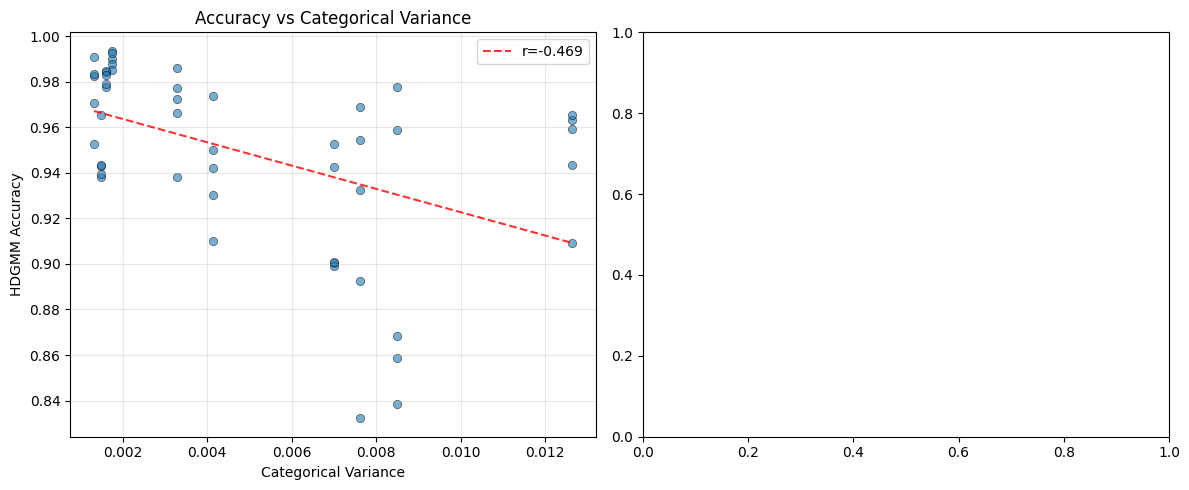


Scatter plots saved to /home/esli/GenParticles_neural_stimulus/analysis_results/variance_scatter.png


In [11]:
# Visualization: Variance vs Accuracy scatter plots

if variance_results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Categorical variance vs accuracy
    valid_cat = [(r['categorical_variance'], r['hdgmm_accuracy']) 
                 for r in variance_results if r['categorical_variance'] is not None]
    if valid_cat:
        cat_vars, accs = zip(*valid_cat)
        axes[0].scatter(cat_vars, accs, alpha=0.6, edgecolor='k', linewidth=0.5)
        axes[0].set_xlabel('Categorical Variance')
        axes[0].set_ylabel('HDGMM Accuracy')
        axes[0].set_title('Accuracy vs Categorical Variance')
        axes[0].grid(alpha=0.3)
        
        if len(valid_cat) > 10:
            z = np.polyfit(cat_vars, accs, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(min(cat_vars), max(cat_vars), 100)
            corr, _ = stats.pearsonr(cat_vars, accs)
            axes[0].plot(x_trend, p(x_trend), 'r--', alpha=0.8, label=f'r={corr:.3f}')
            axes[0].legend()
    
    # Inter-run agreement vs accuracy
    valid_agree = [(r['inter_run_agreement'], r['hdgmm_accuracy']) 
                   for r in variance_results if r['inter_run_agreement'] is not None]
    if valid_agree:
        agrees, accs = zip(*valid_agree)
        axes[1].scatter(agrees, accs, alpha=0.6, edgecolor='k', linewidth=0.5, color='green')
        axes[1].set_xlabel('Inter-Run Agreement')
        axes[1].set_ylabel('HDGMM Accuracy')
        axes[1].set_title('Accuracy vs Inter-Run Agreement')
        axes[1].grid(alpha=0.3)
        
        if len(valid_agree) > 10:
            z = np.polyfit(agrees, accs, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(min(agrees), max(agrees), 100)
            corr, _ = stats.pearsonr(agrees, accs)
            axes[1].plot(x_trend, p(x_trend), 'r--', alpha=0.8, label=f'r={corr:.3f}')
            axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'variance_scatter.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nScatter plots saved to {OUTPUT_DIR}/variance_scatter.png")

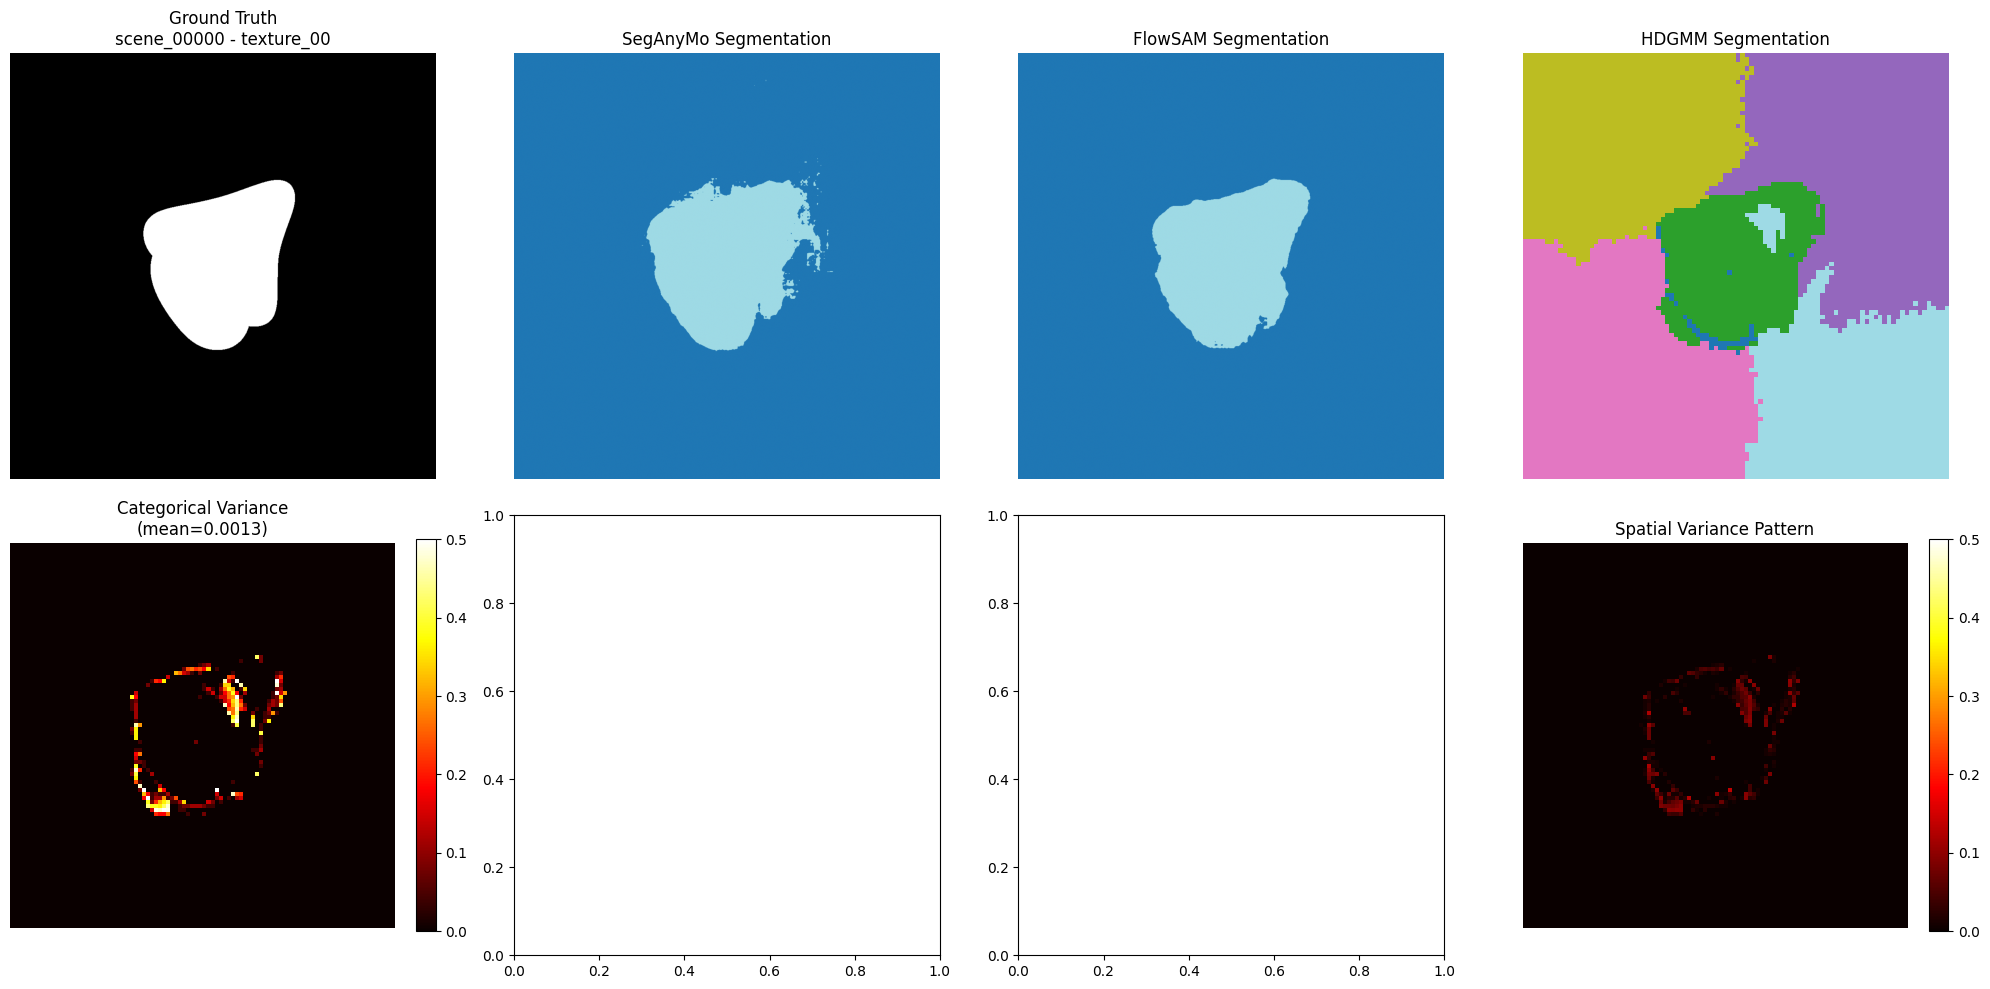


Example visualization saved to /home/esli/GenParticles_neural_stimulus/analysis_results/comparison_example_scene_00000_texture_00.png


: 

In [ ]:
# Visualization: Example segmentation comparison

if existing_combinations:
    scene, texture = existing_combinations[0]
    frame_idx = 0
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Ground truth
    true_mask = load_ground_truth_mask(scene, frame_idx)
    if true_mask is not None:
        axes[0, 0].imshow(true_mask, cmap='gray')
        axes[0, 0].set_title(f'Ground Truth\n{scene} - {texture}')
        axes[0, 0].axis('off')
    
    # SegAnyMo segmentation
    seganymo_mask = load_seganymo_mask(scene, texture, frame_idx)
    if seganymo_mask is not None:
        axes[0, 1].imshow(seganymo_mask, cmap='tab20')
        axes[0, 1].set_title('SegAnyMo Segmentation')
        axes[0, 1].axis('off')
    
    # FlowSAM segmentation
    flowsam_mask = load_flowsam_mask(scene, texture, frame_idx)
    if flowsam_mask is not None:
        axes[0, 2].imshow(flowsam_mask, cmap='tab20')
        axes[0, 2].set_title('FlowSAM Segmentation')
        axes[0, 2].axis('off')
    
    # HDGMM segmentation
    hdgmm_mask = load_hdgmm_mask(scene, texture, frame_idx)
    if hdgmm_mask is not None:
        axes[0, 3].imshow(hdgmm_mask, cmap='tab20')
        axes[0, 3].set_title('HDGMM Segmentation')
        axes[0, 3].axis('off')
    
    # Categorical variance
    pixel_vars, mean_var, spatial_var = analyze_categorical_variance(scene, texture, 0, True)
    if pixel_vars is not None:
        im = axes[1, 0].imshow(pixel_vars[frame_idx], cmap='hot', vmin=0, vmax=0.5)
        axes[1, 0].set_title(f'Categorical Variance\n(mean={mean_var:.4f})')
        axes[1, 0].axis('off')
        plt.colorbar(im, ax=axes[1, 0], fraction=0.046)
    
    # Inter-run agreement
    agreement_map, entropy_map, mean_agreement = compute_inter_run_variance(scene, texture, frame_idx)
    if agreement_map is not None:
        im = axes[1, 1].imshow(agreement_map, cmap='RdYlGn', vmin=0, vmax=1)
        axes[1, 1].set_title(f'Inter-Run Agreement\n(mean={mean_agreement:.3f})')
        axes[1, 1].axis('off')
        plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
    
    if entropy_map is not None:
        im = axes[1, 2].imshow(entropy_map, cmap='viridis')
        axes[1, 2].set_title('Inter-Run Entropy')
        axes[1, 2].axis('off')
        plt.colorbar(im, ax=axes[1, 2], fraction=0.046)
    
    if spatial_var is not None:
        im = axes[1, 3].imshow(spatial_var, cmap='hot', vmin=0, vmax=0.5)
        axes[1, 3].set_title('Spatial Variance Pattern')
        axes[1, 3].axis('off')
        plt.colorbar(im, ax=axes[1, 3], fraction=0.046)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'comparison_example_{scene}_{texture}.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nExample visualization saved to {OUTPUT_DIR}/comparison_example_{scene}_{texture}.png")